<a href="https://colab.research.google.com/github/sadia3160/flood-ale/blob/main/FloodAle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Import Libraries




In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report


###Load and View

>[kaggle dataset modified](https://www.kaggle.com/datasets/emonreza/65-years-of-weather-data-bangladesh-preprocessed) [<small>65 Years of Weather Data Bangladesh Preprocessed from 1948 to 2013</small>] and then used > [Dataset](https://github.com/n-gauhar/Flood-prediction/tree/master)






In [67]:
#flood_file_path = '/content/FloodPrediction.csv'
flood_file_path = 'https://raw.githubusercontent.com/n-gauhar/Flood-prediction/master/FloodPrediction.csv'
flood_data = pd.read_csv(flood_file_path)
flood_data_copy = flood_data.copy()
flood_data.head(10)

,Sl,Station_Names,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Station_Number,X_COR,Y_COR,LATITUDE,LONGITUDE,ALT,Period,Flood?
0,0,Barisal,1949,1,29.4,12.3,0.0,68.0,0.453704,0.6,7.831915,41950,536809.8,510151.9,22.7,90.36,4,1949.01,NaN
1,1,Barisal,1949,2,33.9,15.2,9.0,63.0,0.659259,0.9,8.314894,41950,536809.8,510151.9,22.7,90.36,4,1949.02,NaN
2,2,Barisal,1949,3,36.7,20.2,8.0,59.0,1.085185,1.5,8.131915,41950,536809.8,510151.9,22.7,90.36,4,1949.03,NaN
3,3,Barisal,1949,4,33.9,23.9,140.0,71.0,1.772222,3.9,8.219149,41950,536809.8,510151.9,22.7,90.36,4,1949.04,NaN
4,4,Barisal,1949,5,35.6,25.0,217.0,76.0,1.703704,4.1,7.046809,41950,536809.8,510151.9,22.7,90.36,4,1949.05,NaN
5,5,Barisal,1949,6,34.4,25.7,512.0,80.0,1.631481,5.6,4.072340,41950,536809.8,510151.9,22.7,90.36,4,1949.06,1.0
6,6,Barisal,1949,7,33.4,25.8,575.0,85.0,1.570370,5.4,3.738298,41950,536809.8,510151.9,22.7,90.36,4,1949.07,1.0
7,7,Barisal,1949,8,33.5,25.7,349.0,86.0,1.329630,5.6,4.272340,41950,536809.8,510151.9,22.7,90.36,4,1949.08,1.0
8,8,Barisal,1949,9,34.8,25.7,252.0,83.0,0.937037,4.8,4.823404,41950,536809.8,510151.9,22.7,90.36,4,1949.09,NaN
9,9,Barisal,1949,10,34.0,24.7,128.0,78.0,0.490741,3.1,7.000000,41950,536809.8,510151.9,22.7,90.36,4,1949.10,NaN


###Basic Infos




In [68]:
flood_data.shape    #Rows,Cols

(20544, 19)

In [69]:
flood_data.info()                   #Data Infos
flood_data.describe(include='all')  #Data Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20544 entries, 0 to 20543
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sl                 20544 non-null  int64  
 1   Station_Names      20544 non-null  object 
 2   Year               20544 non-null  int64  
 3   Month              20544 non-null  int64  
 4   Max_Temp           20544 non-null  float64
 5   Min_Temp           20544 non-null  float64
 6   Rainfall           20544 non-null  float64
 7   Relative_Humidity  20544 non-null  float64
 8   Wind_Speed         20544 non-null  float64
 9   Cloud_Coverage     20544 non-null  float64
 10  Bright_Sunshine    20544 non-null  float64
 11  Station_Number     20544 non-null  int64  
 12  X_COR              20544 non-null  float64
 13  Y_COR              20544 non-null  float64
 14  LATITUDE           20544 non-null  float64
 15  LONGITUDE          20544 non-null  float64
 16  ALT                205

,Sl,Station_Names,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Station_Number,X_COR,Y_COR,LATITUDE,LONGITUDE,ALT,Period,Flood?
count,20544.000000,20544,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,20544.000000,4493.000000
unique,NaN,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Bogra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,10271.500000,NaN,1985.332944,6.500000,33.450739,21.166872,198.776621,79.497375,1.415049,3.485827,6.419056,41935.098131,549703.189176,579280.955958,23.326647,90.493193,13.357477,1985.397944,0.919653
std,5930.686301,NaN,17.610799,3.452137,2.956401,4.949587,240.693197,7.667925,1.042454,2.083791,1.747959,36.516932,116032.076255,130616.053201,1.155241,1.108720,13.529530,17.610832,0.271860
min,0.000000,NaN,1948.000000,1.000000,21.600000,6.200000,0.000000,34.000000,0.000000,0.000000,0.000000,41859.000000,0.000000,0.000000,20.870000,88.560000,0.000000,1948.010000,0.000000
25%,5135.750000,NaN,1972.000000,3.750000,31.700000,16.900000,8.000000,75.000000,0.700000,1.600000,4.965517,41909.000000,435303.700000,504500.300000,22.640000,89.550000,4.000000,1972.050000,1.000000
50%,10271.500000,NaN,1987.000000,6.500000,33.900000,23.400000,111.000000,81.000000,1.200000,3.300000,6.800000,41941.000000,540098.600000,561770.300000,23.170000,90.410000,7.000000,1987.040000,1.000000
75%,15407.250000,NaN,2000.000000,9.250000,35.400000,25.400000,312.000000,85.000000,1.900000,5.500000,7.800000,41963.000000,650012.100000,687095.900000,24.290000,91.460000,19.000000,2000.092500,1.000000


###Missing Values

In [70]:
flood_data['Flood?'].value_counts()

,count
Flood?,
1.0,4132
0.0,361


In [71]:
flood_data.isnull().sum()

,0
Sl,0
Station_Names,0
Year,0
Month,0
Max_Temp,0
Min_Temp,0
Rainfall,0
Relative_Humidity,0
Wind_Speed,0
Cloud_Coverage,0


###Visualization Before Data Preprocessing

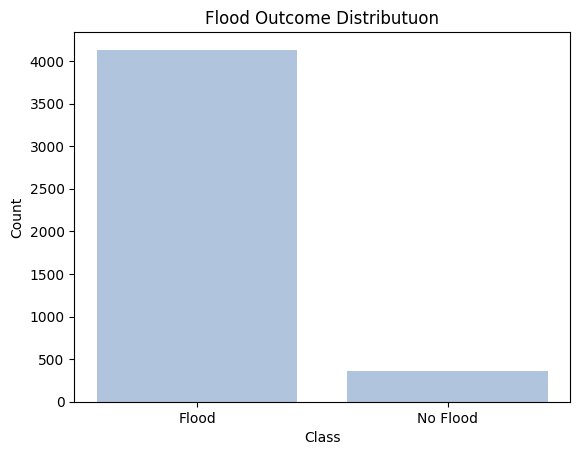

In [72]:
counts = flood_data['Flood?'].value_counts()    #returns list of unqiue values and their occurrance

plt.figure()
x = ['Flood','No Flood', ]
y = counts.values
plt.bar(x, y, color='lightsteelblue')
plt.title('Flood Outcome Distributuon')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

`District VS Flood`

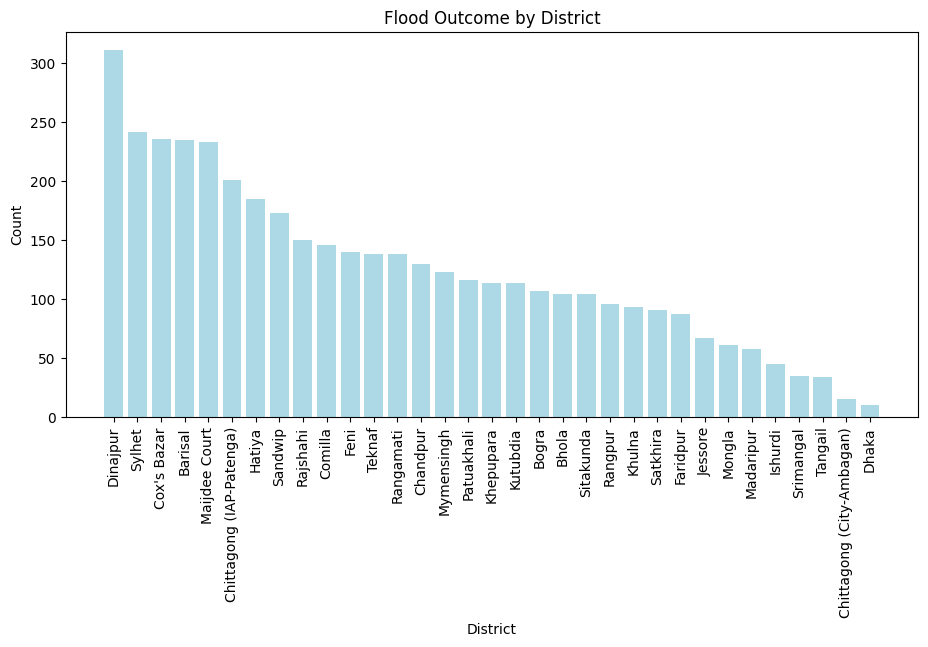

In [73]:
flood_data.rename(columns={'Flood?':'Outcome'}, inplace=True)
x = flood_data.groupby('Station_Names').Outcome.sum().sort_values(ascending=False)

plt.figure(figsize=(11,5))
plt.bar(x.index, x.values, color='lightblue')
plt.xticks(rotation=90)
plt.title('Flood Outcome by District')
plt.xlabel('District')
plt.ylabel('Count')
plt.show()

###Data Preprocessing

**`Data Cleaning`**

In [74]:
#In this Dataset, NaN was used to represent 'No Flood'
#Thus, we inserted zero in place of NaN

flood_data.fillna(0, inplace=True)

In [75]:
flood_data.duplicated().value_counts()    #No duplicates

,count
False,20544


**`Data Reduction`**

In [76]:
flood_data = flood_data.drop(columns={'Sl', 'Station_Number', 'Station_Names'})


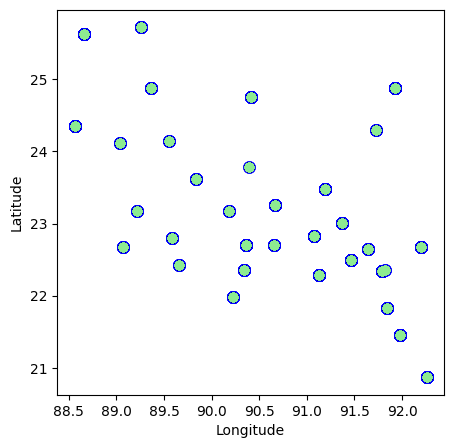

In [77]:
flood = flood_data.loc[flood_data['Outcome']==1]
no_flood = flood_data.loc[flood_data['Outcome']==0]

x1 = flood['LONGITUDE']
y1 = flood['LATITUDE']
x2 = no_flood['LONGITUDE']
y2 = no_flood['LATITUDE']

plt.figure(figsize=(5,5))
plt.scatter(x1,y1,color='blue',alpha=.3, edgecolors='b', linewidths=3)
plt.scatter(x2,y2,color='lightgreen',alpha=.3)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

###Visualization after data preprocessing


In [78]:
counts = flood_data['Outcome'].value_counts()    #returns list of unqiue values and their occurrance
counts

,count
Outcome,
0.0,16412
1.0,4132


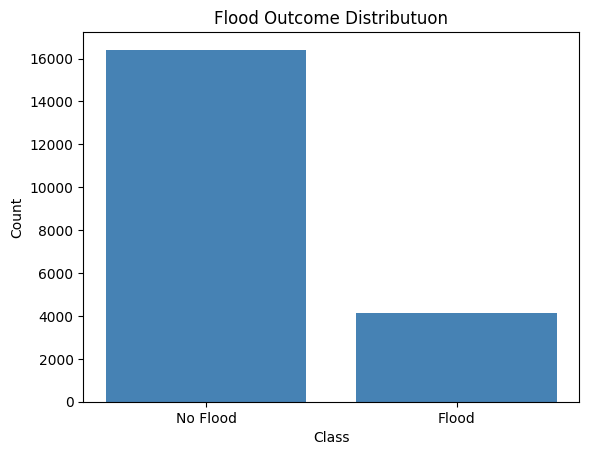

In [79]:
plt.figure()
x = ['No Flood', 'Flood']
y = counts.values
plt.bar(x, y, color='steelblue')
plt.title('Flood Outcome Distributuon')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

`Flood Visualtization by Month`

In [80]:
import folium
from folium import Circle
from folium.plugins import MarkerCluster

map = folium.Map(location=[23.75, 91],tiles='cartodbpositron',zoom_start=7)
cluster = MarkerCluster().add_to(map)

def showFlood(val):
  if val == 1:
    return 'red'

def circle(row):
  if row['Outcome']==1:
    folium.CircleMarker(
          location = [row['LATITUDE'],row['LONGITUDE']],
          radius = 5,
          color= showFlood(row['Outcome']),
          tooltip = row['Year']
    ).add_to(cluster)


flood_data.loc[flood_data['Month']==7].apply(circle, axis=1)

map


**`Feature Distribution`**

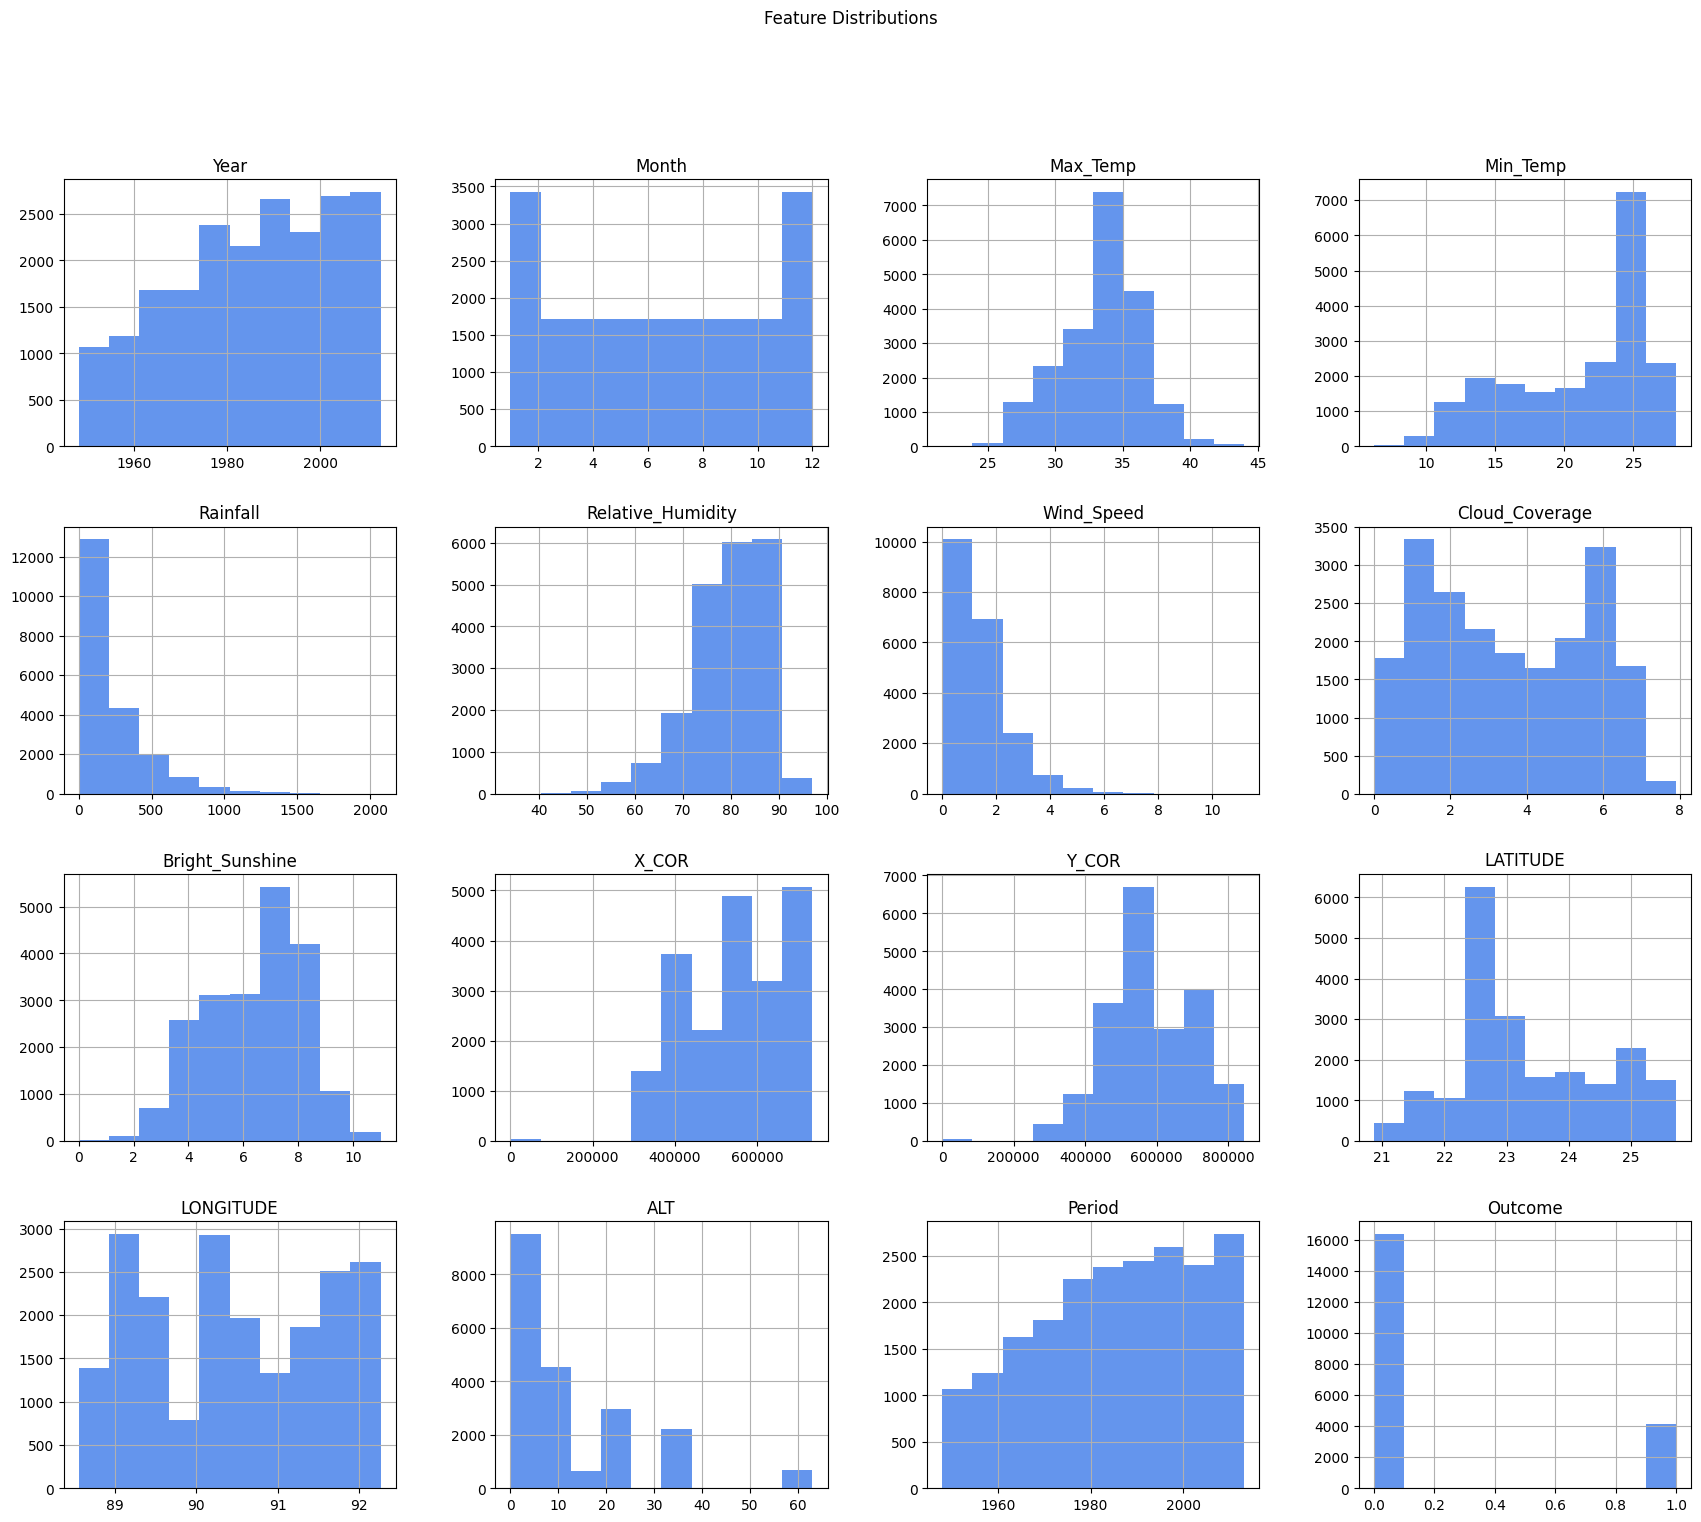

In [81]:
flood_data.hist(figsize=(21,17), color='cornflowerblue')
plt.suptitle('Feature Distributions')
plt.show()

**`Correlation with Target`**

Outcome              1.000000
Rainfall             0.768816
Cloud_Coverage       0.573665
Relative_Humidity    0.459616
Min_Temp             0.412115
Wind_Speed           0.217552
Max_Temp             0.135808
Month                0.105497
LONGITUDE            0.081810
X_COR                0.075751
Period               0.028370
Year                 0.028163
ALT                  0.012619
LATITUDE            -0.054983
Y_COR               -0.056238
Bright_Sunshine     -0.551552
Name: Outcome, dtype: float64


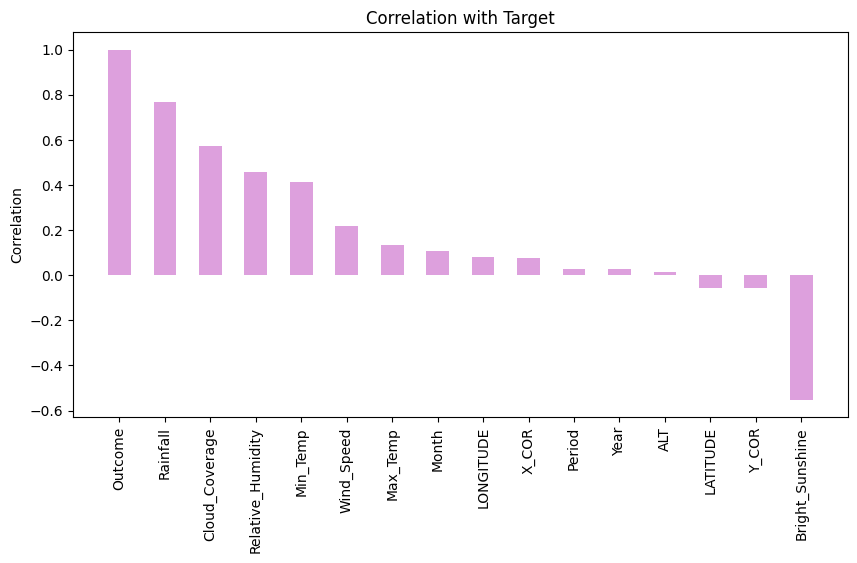

In [82]:
all_corr = flood_data.corr() #Standard correlation coefficient/Pearson's r (-1 to 1)

target_corr = all_corr['Outcome'].sort_values(ascending=False)
print(target_corr)
plt.figure(figsize=(10,5))
plt.bar(target_corr.index, target_corr.values, color = 'plum', width=.5)
plt.xticks(rotation=90)
plt.ylabel('Correlation')
plt.title('Correlation with Target')
plt.show()


**`Correlation Heatmap`**

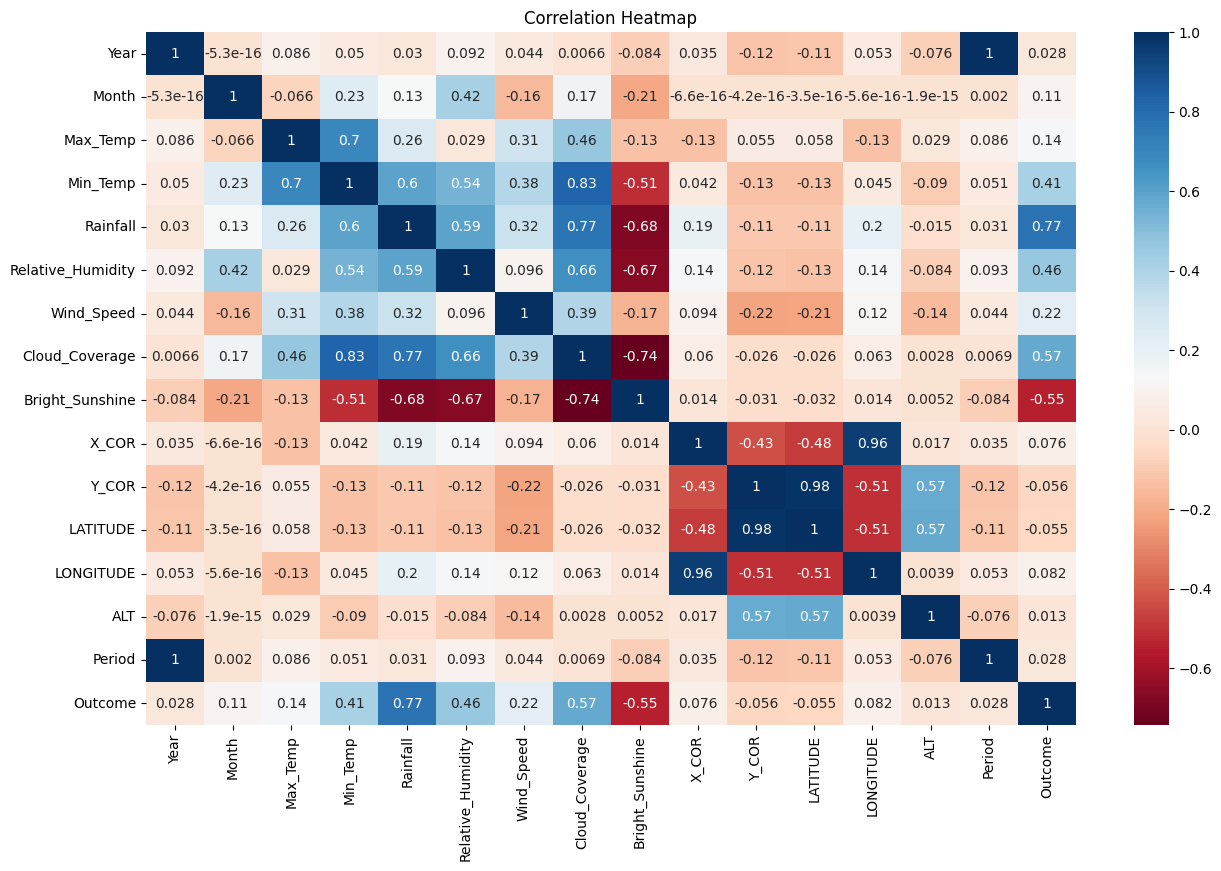

In [83]:
plt.figure(figsize=(15,9))
sns.heatmap(all_corr, annot=True, cmap='RdBu')
plt.title('Correlation Heatmap')
plt.show()

#close to 1 > strong +ve correlation
#close to -1 > strong -ve correlation

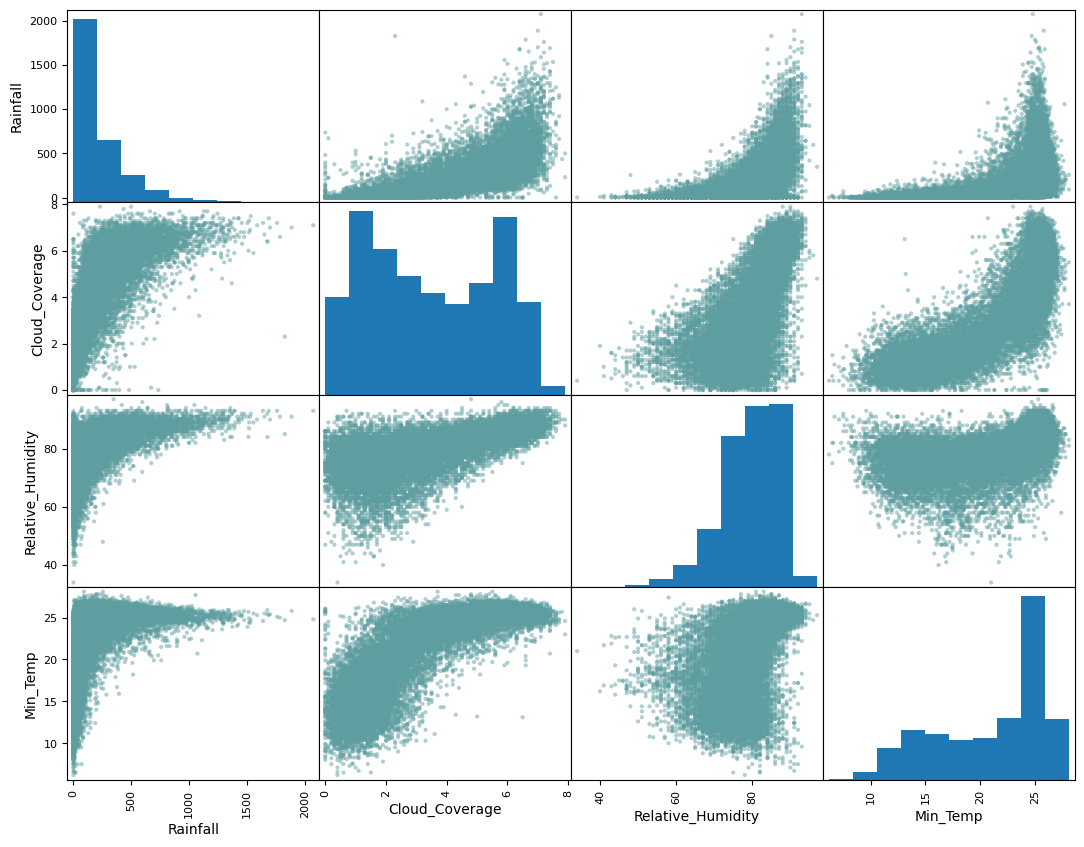

In [84]:
#scattar_matrix of important features
from pandas.plotting import scatter_matrix

majors=['Rainfall','Cloud_Coverage','Relative_Humidity','Min_Temp']
scatter_matrix(flood_data[majors],figsize=(13,10),color='cadetblue')
plt.show()

###Data Splitting

In [85]:
flood_data.shape

(20544, 16)

In [86]:
#Features
X = flood_data.drop(columns=['Outcome'])

In [87]:
#Labels
y = flood_data['Outcome']

In [88]:
#Train and Validation Data
X_train, val_X, y_train, val_y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratified sampling

###Feature Scaling

In [89]:
scalar = StandardScaler()

X_train = scalar.fit_transform(X_train) #fit then transform
val_X = scalar.transform(val_X)

In [90]:
val_X[0]

array([-2.06051808,  0.14897473,  0.1138511 ,  0.69216443,  0.46028502,
        1.24128135, -0.34215308,  1.4470715 , -1.19905289,  1.08381284,
        0.82469251,  0.83303038,  1.11276652,  0.71651113, -2.0602356 ])

In [91]:
X_train[0]

array([ 0.0393878 ,  0.43893207,  0.68891705,  1.03567155,  1.00790129,
        0.19331608, -1.06502188,  1.15884477, -1.41811226, -0.26964287,
       -0.13456698, -0.13596658, -0.28532918, -0.61841863,  0.04024712])

###KNN

In [92]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [93]:
knn_pred = knn.predict(val_X)
score = knn.score(val_X, val_y)
score

0.9452421513750304

###Decision Tree

In [94]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [95]:
dt.predict(val_X)
score = dt.score(val_X, val_y)
score

0.9671452908250182

###Random Forest

In [96]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [97]:
rf.predict(val_X)
score = rf.score(val_X, val_y)
score

0.9746897055244585

###Support Vector Machines (SVM)

In [98]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

SVC(random_state=42)

In [99]:
svm.predict(val_X)
score = svm.score(val_X, val_y)
score

0.9578972986128012

###XGBoost

In [100]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [101]:
xgb.predict(val_X)
score = xgb.score(val_X, val_y)
score

0.9785835969822341

###Logistic Regression

In [102]:
rbs = RobustScaler()
xt = rbs.fit_transform(X_train)
xv = rbs.fit(val_X)

lr = LogisticRegression(C=.1, solver='liblinear',random_state=42)
lr.fit(xt, y_train)

LogisticRegression(C=0.1, random_state=42, solver='liblinear')

###Model Analysis

In [103]:
#Models
models = [knn, dt, rf, svm, xgb,lr]

#Model Names
def model_name(model_title):
  title=''
  for i in model_title:
    if i != '(':
      title += i
    else:
      break
  return title

**`Confusion Matrics`**

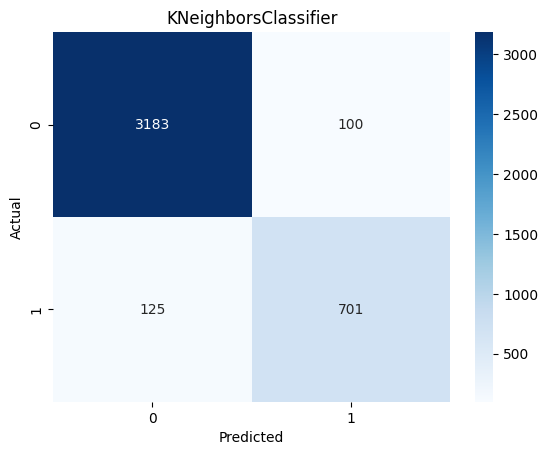

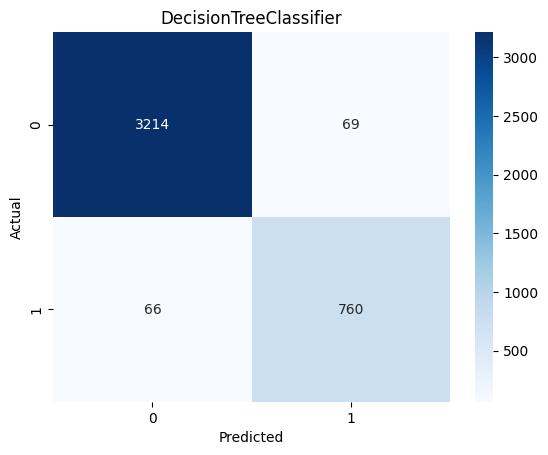

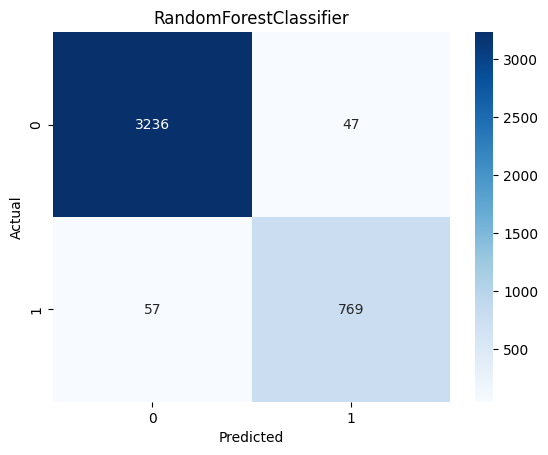

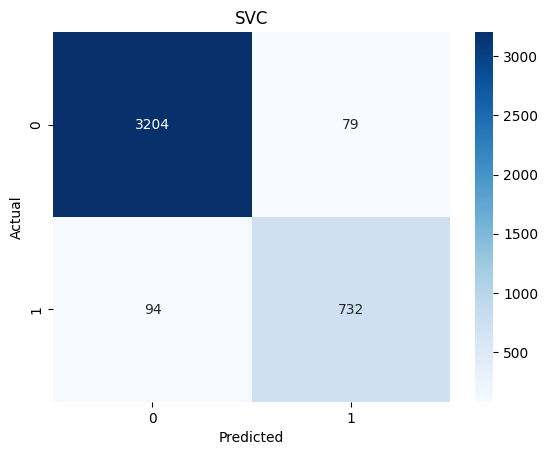

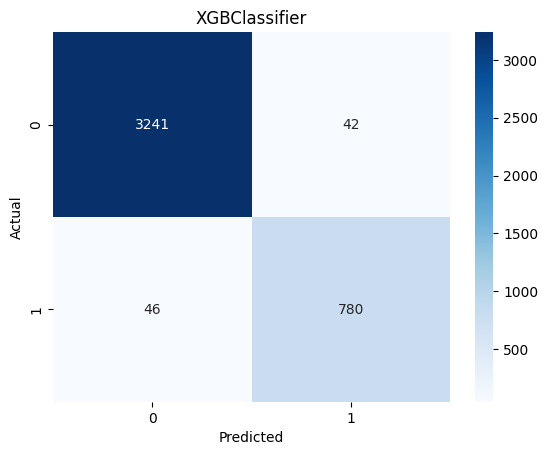

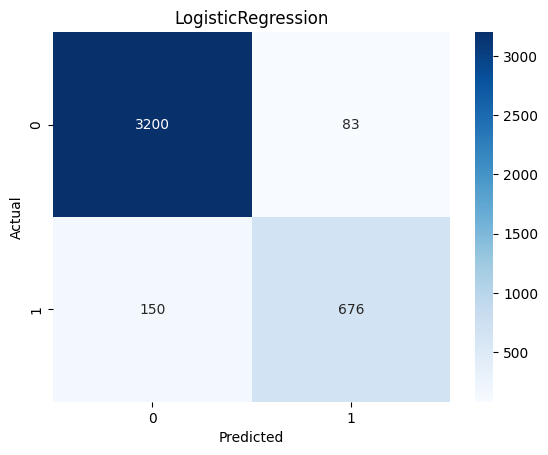

In [104]:
for model in models:

  y_pred = model.predict(val_X)
  cm = confusion_matrix(val_y, y_pred)

  plt.figure()
  plt.title(model_name(str(model)))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()


**`Classfication Report`**

In [105]:
for model in models:
  y_pred = model.predict(val_X)

  print(model_name(str(model)) + '\n-----------------------')
  print(classification_report(val_y, y_pred))

KNeighborsClassifier
-----------------------
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97      3283
         1.0       0.88      0.85      0.86       826

    accuracy                           0.95      4109
   macro avg       0.92      0.91      0.91      4109
weighted avg       0.94      0.95      0.94      4109

DecisionTreeClassifier
-----------------------
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3283
         1.0       0.92      0.92      0.92       826

    accuracy                           0.97      4109
   macro avg       0.95      0.95      0.95      4109
weighted avg       0.97      0.97      0.97      4109

RandomForestClassifier
-----------------------
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      3283
         1.0       0.94      0.93      0.94       826

    accuracy                           0.97

**`Cross Validation`**

In [106]:
for model in models:
  cv_score = cross_val_score(model, X, y, cv=5)
  print(model_name(str(model)) + ':')
  print('CV Score = ', cv_score)
  print('CV Score mean = ', np.mean(cv_score))
  print('\n')

KNeighborsClassifier:
CV Score =  [0.93234364 0.79922122 0.8958384  0.92942322 0.93330088]
CV Score mean =  0.8980254709601528


DecisionTreeClassifier:
CV Score =  [0.92674617 0.8958384  0.9425651  0.874422   0.92259007]
CV Score mean =  0.9124323480198667


RandomForestClassifier:
CV Score =  [0.93210027 0.91895838 0.97347286 0.94548552 0.94912366]
CV Score mean =  0.9438281393848211


SVC:
CV Score =  [0.79897785 0.79897785 0.79873449 0.79873449 0.79892892]
CV Score mean =  0.7988707193438395


XGBClassifier:
CV Score =  [0.93112679 0.91336092 0.92260891 0.93453395 0.94912366]
CV Score mean =  0.9301508456393842


LogisticRegression:
CV Score =  [0.92552933 0.9104405  0.96154782 0.93867121 0.96032132]
CV Score mean =  0.9393020355962154




###Hyperparameter Tuning


In [107]:
from sklearn.model_selection import GridSearchCV

`KNN`

In [108]:
#KNN, DT, RF, SVM, XGB, LR

knn2 = KNeighborsClassifier()
param_grid = {
    'n_neighbors' : [3, 5, 7, 9, 11, 13, 15],
    'weights' : ['uniform', 'distance'],
}
knn2_gscv = GridSearchCV(knn2, param_grid, cv=5, n_jobs=-1, verbose=2)
knn2_gscv.fit(X_train, y_train)

knn2_gscv.best_params_

Fitting 5 folds for each of 14 candidates, totalling 70 fits


{'n_neighbors': 13, 'weights': 'distance'}

In [109]:
knn2_bs = knn2_gscv.best_score_ #avg cv score of best combination
knn2_bs

np.float64(0.94742926680864)

`Decision Tree`

In [110]:
dt2 = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth' : [3,5,7,9,11],
    'min_samples_split' :[10,15,20,25]
}
dt2_gscv = GridSearchCV(dt2, param_grid, cv=5,n_jobs=-1, verbose=2)
dt2_gscv.fit(X_train, y_train)

dt2_gscv.best_params_



Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'max_depth': 7, 'min_samples_split': 20}

In [111]:
dt2_bs = dt2_gscv.best_score_
dt2_bs

np.float64(0.9694554304837236)

`Random Forest`

In [112]:
rf2 = RandomForestClassifier(random_state=42)
param_grid = {
    'max_depth' : [10,15,20,25],
    'n_estimators' :[200,300,500]
}
rf2_gscv = GridSearchCV(rf2, param_grid, cv=5,n_jobs=-1, verbose=2)
rf2_gscv.fit(X_train, y_train)

rf2_gscv.best_params_



Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'max_depth': 15, 'n_estimators': 200}

In [113]:
rf2_bs = rf2_gscv.best_score_
rf2_bs

np.float64(0.9735320961362944)

`Support Vector Machine`

In [114]:
svm2 = SVC(random_state=42)
param_grid = {
    'kernel':['linear','rbf'],
    'gamma':['scale','auto'],
}
svm2_gscv = GridSearchCV(svm2, param_grid, cv=5,n_jobs=-1, verbose=2)
svm2_gscv.fit(X_train, y_train)

svm2_gscv.best_params_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'gamma': 'auto', 'kernel': 'rbf'}

In [115]:
svm2_bs = svm2_gscv.best_score_
svm2_bs

np.float64(0.958685731670216)

`Extreme Gradient Boosting Classifier`

In [116]:
xgb2 = XGBClassifier(random_state=42)
param_grid = {
    'max_depth' : [3,5,10,15],
    'learning_rate' :[0.01,0.05,1.0]
}
xgb2_gscv = GridSearchCV(xgb2, param_grid, cv=5,n_jobs=-1, verbose=2)
xgb2_gscv.fit(X_train, y_train)

xgb2_gscv.best_params_



Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'learning_rate': 0.05, 'max_depth': 10}

In [117]:
xgb2_bs = xgb2_gscv.best_score_
xgb2_bs

np.float64(0.9759050806206266)

`Logistic Regression`

In [118]:
lr2 = LogisticRegression(random_state=42)
param_grid = {
    'C' : [.1,.5,1.0,10],
    'solver' :['liblinear','lbfgs','saga'],
    'max_iter':[100, 500, 1000]
}
lr2_gscv = GridSearchCV(lr2, param_grid, cv=5,n_jobs=-1, verbose=2)
lr2_gscv.fit(X_train, y_train)

lr2_gscv.best_params_



Fitting 5 folds for each of 36 candidates, totalling 180 fits


{'C': 0.5, 'max_iter': 100, 'solver': 'lbfgs'}

In [119]:
lr2_bs = lr2_gscv.best_score_
lr2_bs

np.float64(0.9470033465165806)

###Best Model

In [120]:
#Best Score from GridSearchCV
all_model = ['KNN', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoostClassifier', 'Logistic Regression']
all_bs = [knn2_bs, dt2_bs, rf2_bs, svm2_bs, xgb2_bs,lr2_bs]
i=0
print(f"Best Scores:")
for bs in all_bs:
  print(f"{all_model[i]}: {bs:.5f}")
  i+=1

Best Scores:
KNN: 0.94743
Decision Tree: 0.96946
Random Forest: 0.97353
SVM: 0.95869
XGBoostClassifier: 0.97591
Logistic Regression: 0.94700


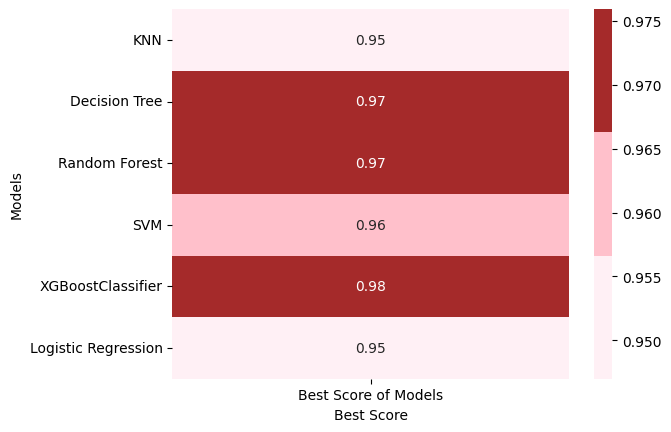

In [121]:
plt.figure()
bs = [[knn2_bs], [dt2_bs], [rf2_bs], [svm2_bs], [xgb2_bs],[lr2_bs]]
bc = ['lavenderblush','pink','brown']
sns.heatmap(bs, annot=True, xticklabels=['Best Score of Models'],yticklabels=all_model,cmap=sns.color_palette(bc,as_cmap=True))
plt.xlabel('Best Score')
plt.ylabel('Models')
plt.show()

`Classification report comparision`

In [122]:
nmodels = [knn2_gscv, dt2_gscv, rf2_gscv, svm2_gscv, xgb2_gscv,lr2_gscv]
all_f1=[]
i=0
for model in nmodels:
  y_pred = model.predict(val_X)
  print(str(all_model[i]) + '\n-----------------------')
  print(classification_report(val_y, y_pred))
  report = classification_report(val_y, y_pred,output_dict=True)
  all_f1.append(report['macro avg']['f1-score'])
  i += 1

KNN
-----------------------
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      3283
         1.0       0.90      0.85      0.88       826

    accuracy                           0.95      4109
   macro avg       0.93      0.92      0.92      4109
weighted avg       0.95      0.95      0.95      4109

Decision Tree
-----------------------
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3283
         1.0       0.93      0.92      0.92       826

    accuracy                           0.97      4109
   macro avg       0.95      0.95      0.95      4109
weighted avg       0.97      0.97      0.97      4109

Random Forest
-----------------------
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      3283
         1.0       0.94      0.93      0.94       826

    accuracy                           0.97      4109
   macro avg       0.96 

`f1 score`

In [123]:
all_f1

[0.9234555287104569,
 0.9528129454614425,
 0.9603875445869083,
 0.934015538892855,
 0.9673924999077252,
 0.9189688823379603]

In [124]:
#get f1
def f1p():
  i=0
  for model in all_model:
    print(f"{model}:{all_f1[i]:.5f}")
    i+=1

KNN:0.92346
Decision Tree:0.95281
Random Forest:0.96039
SVM:0.93402
XGBoostClassifier:0.96739
Logistic Regression:0.91897


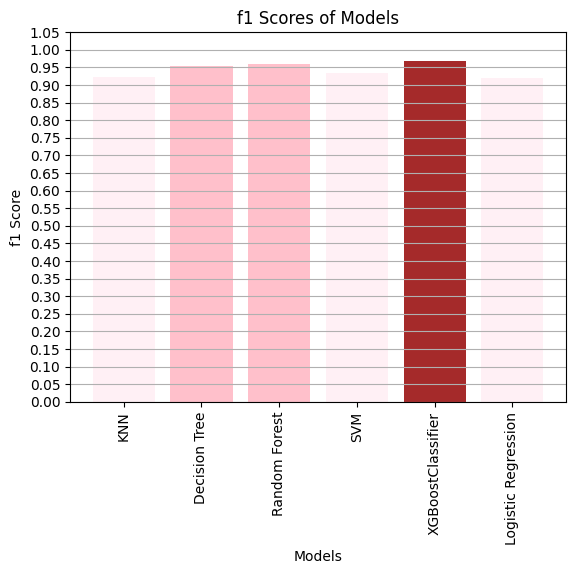

In [125]:
f1p()
plt.figure()
c = ['lavenderblush','pink','pink','lavenderblush','brown','lavenderblush']
plt.bar(all_model, all_f1, color=c)
plt.yticks(np.arange(0.0,1.10,.05))
plt.grid(True,axis='y')
plt.xticks(rotation=90)
plt.xlabel('Models')
plt.ylabel('f1 Score')
plt.title('f1 Scores of Models')
plt.show()

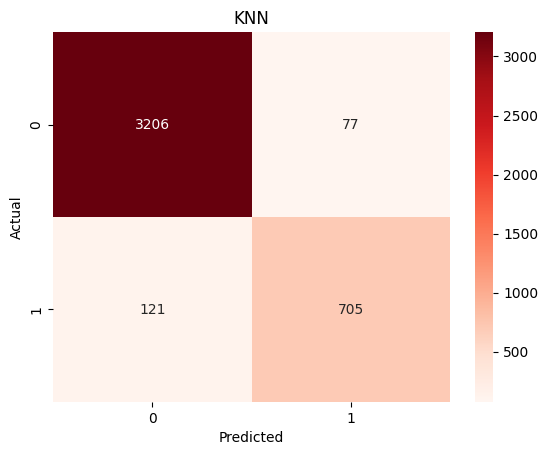

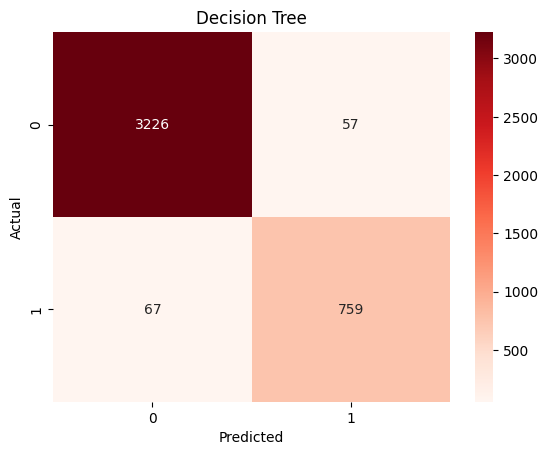

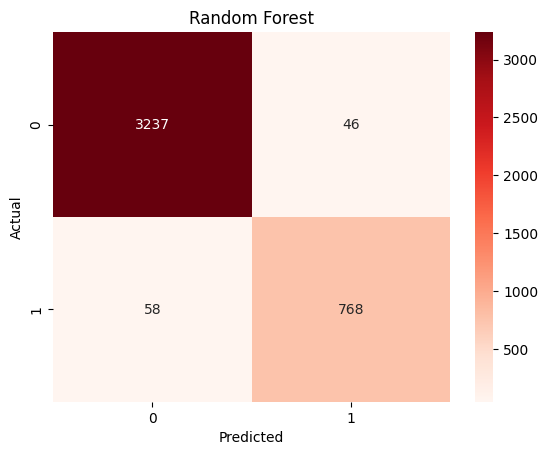

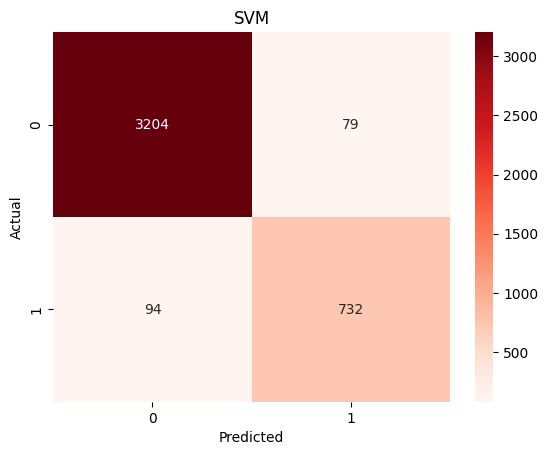

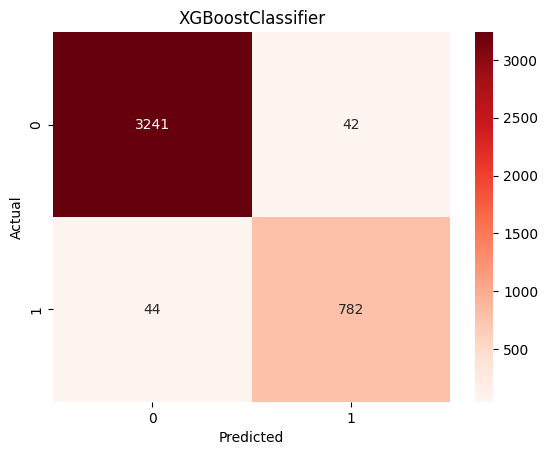

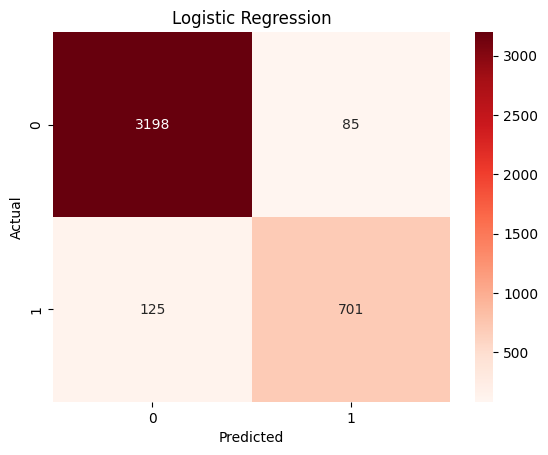

In [126]:
i=0
for model in nmodels:

  y_pred = nmodels[i].predict(val_X)
  cm = confusion_matrix(val_y,y_pred)

  plt.figure()
  plt.title(all_model[i])
  sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()
  i+=1



#**SO, XGBOOST IS THE WINNER**
#####Random Forest in the RUNNER-UP


---






`Inference`

Three Data Instances manually collected from [Climate Information Management System](https://apps.barc.gov.bd/climate/dashboard) of Bangladesh Agricultural Research Council
* Data instance 1: Month of January, 2023 - No flood occured in Sylhet
* Data instance 2: Month of June, 2022 - flood occured in Sylhet
* Data instance 3: Month of August, 2023 - flood occured in Chittagong

In [127]:
test_flood = pd.DataFrame(
    {
	     'Year':[2023,2022,2023],
       'Month': [1, 6, 8],
       'Max_Temp': [26.48, 29.85,31.26],
       'Min_Temp': [13.92, 24.54,26.13],
       'Rainfall': [0, 148.50, 109.80],
       'Relative_Humidity': [72.97, 89.87, 85.47],
       'Wind_Speed': [2.29, 3.65, 3.08],
       'Cloud_Coverage': [0.72, 7.70,6.94],
       'Bright_Sunshine': [6.51, 1.23, 2.53],
       'X_COR':[694533.2, 694533.2, 684570.9],
       'Y_COR':[752277.9, 752277.9, 471415.0],
       'LATITUDE':[24.88, 24.88, 22.34],
       'LONGITUDE':[91.93, 91.93, 91.79],
       'ALT':[35,35, 6],
       'Period':[2023.01, 2022.06, 2023.08]
    }
)


test_flood




,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,X_COR,Y_COR,LATITUDE,LONGITUDE,ALT,Period
0,2023,1,26.48,13.92,0.0,72.97,2.29,0.72,6.51,694533.2,752277.9,24.88,91.93,35,2023.01
1,2022,6,29.85,24.54,148.5,89.87,3.65,7.70,1.23,694533.2,752277.9,24.88,91.93,35,2022.06
2,2023,8,31.26,26.13,109.8,85.47,3.08,6.94,2.53,684570.9,471415.0,22.34,91.79,6,2023.08


In [128]:
test_flood_outcome = xgb2_gscv.predict(test_flood)
pd.DataFrame({'Outcome':test_flood_outcome},index=['Jan, 2023 (Sylhet)', 'June, 2022 (Sylhet)', 'August, 2023 (Chittagong)'])

,Outcome
"Jan, 2023 (Sylhet)",0
"June, 2022 (Sylhet)",1
"August, 2023 (Chittagong)",1


###Joblib

In [129]:
import joblib

In [130]:
joblib.dump(xgb2_gscv, 'FloodAle.joblib')

['FloodAle.joblib']